# Introduction

(*Text here and in the background section is partially taken from the [article by Luka Monticelli et al](https://doi.org/10.1038/nnano.2008.130)*)

Recent toxicology studies suggest that nanosized aggregates of fullerene molecules can enter cells and alter their functions, and also cross the blood–brain barrier. However, the mechanisms by which fullerenes penetrate and disrupt cell membranes are still poorly understood. Here we use computer simulations to explore the aggregation of fullerenes, translocation of their clusters through a model lipid membrane and the effect of high fullerene concentrations on membrane properties. We will also analyse the free energy profiles for a single fullerene entering/leaving the membrane.

# Background

The mechanism of nano-C60 penetration through a lipid membrane has not yet been established. The mechanism of cell membrane disruption is also not well understood. In the original study by Monticelli et al, the authors describe the thermodynamics and mechanism of the permeation of fullerene aggregates through cell membranes, based on computer simulations. They developed a coarse-grained (CG) model based on experimental partitioning of fullerene between polar and non-polar phases. The original work, as well as its repetition in this lab, provides insight into the thermodynamics of fullerene clusters permeation through cell membranes and the effect of high concentrations of fullerene on the structural and elastic properties of a lipid bilayer.

# Setting up the environment (common for all)

In [ ]:
# Installing necessary packages
!pip install py3Dmol

In [ ]:
# Cloning the course repository
!git clone https://github.com/computationalpharmaceutics/3FG005.git

In [ ]:
import os
os.chdir('/content/3FG005/Lab04_Nanoparticles')
!ls -l

In [ ]:
# If GPU available, copying the gromacs_intall.tar.gz file from the path to the content file
!cp /content/3FG005/Lab01_peptide_aggregation/GROMACS_GPU_T4/gromacs_install.tar.gz /content

In [ ]:
# Unpacking the file gromacs_install.tar.gz  and creating the folder:  /usr/local/gromacs
!tar -xzf /content/3FG005/Lab01_peptide_aggregation/GROMACS_GPU_T4/gromacs_install.tar.gz -C /

In [ ]:
# Confirm it's installed
!/usr/local/gromacs/bin/gmx --version

In [ ]:
# Seting the path to GROMACS
import os
os.environ["PATH"] += ":/usr/local/gromacs/bin"

# Looking for the working directory
!pwd

In [ ]:
!apt-get update && apt-get install -y packmol

# Part 1: Simulation of the fullerene molecules in water

In this part of the lab we want to see what is the behaviour of the fullerenes in water. Basically, we want to know whether the molecules aggregate or not. This part is a good training ground for several common routines in MD simulations. In the previous exercises you already used some of the command gromacs commands, like gmx grompp and gmx mdrun. It is always necessary to control the output of the commands and at least check the warning/error messages, as otherwise the output might be completely unphysical. However, one can run simulations in a more automatic way, where a script takes care of the sequence of the commands.

Let's first prepare the input files for the simulation. The fullerene molecule can be observed from the supplementary material to the original paper. It is also available in the archive with files for the simulation.

In [ ]:
# Changing the working directory to

import os
os.chdir('/content/3FG005/Lab04_Nanoparticles/Part1') # REPLACE
!pwd

In [ ]:
# Remove temporary files from the folder (if there are any)
!rm *#*

In [ ]:
# First let's take a look at the files available in the directory
!ls -l

The first file is called F16.pdb. You can take a look at its contents with any text editors (vim, nano, atom, nedit, gedit, etc) available on your computer or on the virtual machine. As you probably already know, pdb files contain coordinates of each of the beads representing the molecule. There can also be more information (please see [the format here](https://en.wikipedia.org/wiki/Protein_Data_Bank_(file_format)), if you are interested), but we will not focus on it here.

In [ ]:
# The following command will show the contents of the file F16.pdb (coordinates
# of the atoms in the fullerene molecule).

!cat F16.pdb

Another important file is called F16.itp. It is a topology file, that describes the types of the beads we use for that specific molecule from the force field (FF), as well as how the atoms are bonded between themselves (harmonic, angular bonds and dihedrals). Some additional information, including illustrative videos of dihedrals, can be found on [the CHARMM FF webpage](https://www.charmm-gui.org/?doc=lecture&module=scientific&lesson=9).

The force field we will be using is called Martini. It is one of the most common coarse-grained (CG) force fields. Every bead in Martini of the version 2 is normally representing 4 heavy atoms, thus reducing the number of beads necessary to simulate the system, as well as increasing the timestep, at which the simulation can be run. For more information please check [the official MartiniCG webpage](http://cgmartini.nl/index.php/about).

If you want to hide the output of a command (to not scroll over it when going up and down in the notebook), you can click on the arrow symbol at the beginning of the output cell and choose "show/hide output".

In [ ]:
!cat F16.itp

For this first simulation we will only need two types of molecules: fullerene and water. We will put **30 nanoparticles** and **4000 water molecules** together into a relatively small simulation box (6 x 6 x 6 nm). In one of the previous labs you set up the system using commands gmx insert-molecules and gmx solvate. Here we will use an alternative way, namely software "Packmol", that can put together the molecules without overlapping. An example of the input file (input.packmol) is included in the folder Part1. There you can see the blocks of the commands, defining the components of the system to be built and the number of the molecules, as well as the distribution of those in the initial box.

In [ ]:
!cat input.packmol

If you want, you can change the numbers of the molecules and the box size, but then you need to remember to edit it in other files, such as *system.top*, to make it match and work.

In [ ]:
# to replace the numbers you can for example use the command "sed"
# OPTIONAL, no need to run it. If you want to run anyways, please uncomment the
# next two lines
#!sed -i -e "s/number 30/number 40/g" input.packmol # to replace 30 fullerens with 20
#!sed -i -e "s/number 4000/number 5000/g" input.packmol # to replace 4000 water molecules with 5000

# if you decide to do it, you should do it before the actual packmol <
# input.packmol execution


In [ ]:
# also, in case you change the numbers, use the same command to edit the
# topology file

!cat system.top

In [ ]:
# OPTIONAL, uncomment before running if you want to change the number of
# molecules
#!sed -i -e "s/F16 30/F16 40/g" system.top # to replace 30 fullerens
# with 20
#!sed -i -e "s/W 4000/W 5000/g" system.top # to replace 4000 water
# molecules with 5000 %%

In [ ]:
!packmol < input.packmol

Once the system is assembled, a new pdb file will be created in that folder - mind the output in the terminal, the new .pdb file wil be mentioned there, at the end. Alternatively, you can open the input.packmol file and see the name of the new file in the output filename field (you can find the *!cat input.packmol* cell above or create a new one and run). You need to use this name (taken without extension) further instead of "filenameX". In order to continue the simulation we need to add the box borders to the introduced molecules. The simplest way to do so is to to use **gmx editconf** with a **-d** key. It basically makes the box boundary with an offset (in our case of 0.1 nm) from the most remote atoms in each directions. So, the box borders will be put 0.1 nm to the left from the leftmost atom (in X dimension), 0.1 nm to the right from the rightmost atom, and so on for all 6 walls of the box. **-c** in the command puts the cemter of mass of the molecules into the center of the newly created box.

In [ ]:
# Replace the "filenameX" parts with the actual file name of the output
# from packmol ("Solution: fullerenes_water.pdb").
# If you are getting an error, you need to check the filenames.

!gmx editconf -f filenameX.pdb -o filenameX.gro -c -d 0.1


#!gmx editconf -f fullerenes_water.pdb -o fullerenes_water.gro -c -d 0.1

Apart from that we will need to create an index file for the contents of the box. That can be done with the gmx make_ndx command **gmx make_ndx**. By default the output file will be called *index.ndx*. **Read the instructions that will show up on your screen in order to complete the command. You will need to save the proposed stracture by typing in "q" and submitting.**

In [ ]:
# Remember to replace filenameX with the qactual filename
!gmx make_ndx -f filenameX.gro

# Solution
# !gmx make_ndx -f fullerenes_water.gro

With that done, we just need to make sure the contents of the newly constructed system match the ones described in the system.top file. Use the lines below to check that the order of the molecules is the same, as in the input.packmol file that you used.

In [ ]:
!echo -e "What we compiled with packmol:\n"
!cat input.packmol
!echo -e "\nWhat we specified in system.top:"
!tail -n 5 system.top

If everything is in order, the numbers for F16 and W will be the same in both files, otherwise we need to adjust them in one of the files.

Now let's make one step of the simulation in a usual way. Set up the first simulation stage with gmx grompp and gmx mdrun. **Please remember to replace the names with the actual file names!**

In [ ]:
# Remember to replace filenameX with the actual filename
# Setting up the executable file for the minimization step of the simulation
!gmx grompp -f step6.0_minimization.mdp -o step6.0_minimization.tpr -c filenameX.gro -r filenameX.gro -p system.top -n index.ndx

# Solution
# !gmx grompp -f step6.0_minimization.mdp -o step6.0_minimization.tpr -c fullerenes_water.gro -r fullerenes_water.gro -p system.top -n index.ndx

In [ ]:
# Let's run the minimization for our molecules
!gmx mdrun -nt 1 -deffnm step6.0_minimization

Take a look at the output of the commands - were there any errors or warnings or errors? Notes are usually harmless, just informing you about what was adjusted in your input by gromacs.

Make sure the commands worked right and that you got the file step6.0_minimization.gro as a result of them.

In [ ]:
# prompt: if step6.0_minimization.gro is present, print "step6.0_minimization.gro is created", otherwise "either it is still running or there must be an error in the cell above"

if os.path.exists('step6.0_minimization.gro'):
  print("File step6.0_minimization.gro is created")
else:
  print("either it is still running or there must be an error in the cell above")

Let's see if the energy has reached a plateau. The following command will allow you to prompt a number that corresponds to the potential energy. At the prompt, type '4 0' to select Potential (4, but double check when you run the command); and zero (0) terminates input. This will generate a file named as 'potential.xvg'.

In [ ]:
# Obtaining the energy minimization profile
!gmx energy -f step6.0_minimization.edr -o potential.xvg

In [ ]:
# Plot the energy profile from the minimization step
import matplotlib.pyplot as plt
import numpy as np
import os

# Define the path to your .xvg file
xvg_file = 'potential.xvg'

# Check if the file exists
if not os.path.exists(xvg_file):
    print(f"Error: {xvg_file} not found. Make sure the file exists.")
else:
    # Read the data from the .xvg file
    # We need to skip lines that start with # or @ as they are comments or metadata
    data = []
    with open(xvg_file, 'r') as f:
        for line in f:
            line = line.strip()
            if not line.startswith(('#', '@')) and line:
                try:
                    # Split the line and convert values to float
                    x, y = line.split()
                    data.append([float(x), float(y)])
                except ValueError:
                    # Handle potential errors if a line doesn't have two numbers
                    print(f"Skipping line due to parsing error: {line}")

    # Convert the list of lists into a NumPy array
    data = np.array(data)

    # Check if any data was read
    if data.size > 0:
        # Extract the columns (time and potential energy)
        time = data[:, 0]
        potential_energy = data[:, 1]

        # Plot the data
        plt.figure(figsize=(10, 6)) # Optional: Set the figure size
        plt.plot(time, potential_energy)

        # Set the y-axis to a logarithmic scale
        plt.yscale('log')

        plt.xlabel('Time (ps)') # Update with the correct unit from your .xvg file if different
        plt.ylabel('Potential Energy (kJ/mol)') # Update with the correct unit
        plt.title('Potential Energy Minimization Profile (Log Scale)')
        plt.grid(True) # Optional: Add a grid
        plt.show()
    else:
        print(f"No valid data found in {xvg_file} to plot.")

It is just one of the steps needed to equilibrate the system, but there should be many more of those to gradually increase the timestep.  Moreover, one needs to use the output of the previous step as an input for the next one, thus it is important to stay focused. An alternative way, that we could use in the rest of the exercises is to use the script instead. A script is a set of commands that are executed according to the programming rules. Feel free to open the script file **Run_equilibration.sh** and look through its structure. You will find that there are several places where the gmx grompp and gmx mdrun are run. They are even run in a "while" loop, which means that the body of the loop will be executed while the condition is met (that all 6 steps of the equilibration are done). The point of that script is to automatise the process of the simulation and to perform the repetitive steps without manual labour.

In [ ]:
# Take a look at the script that will streamline the process of several
# quilibration steps in order to prepare the system for the production run

!cat Run_equilibration.sh

As coming from one step to another, the timestep ("dt" in the .mdp files) in the simulations will be increased and some other parameters will eventually change. Such scripts are normally either produced by additional software (as in this case, by CHARMM-GUI), or written manually. If some set up is common for many simulations it can also serve a time-saving tool (i.e. you need to run the same simulation at several concentrations or with different nanoparticle or drug molecules - the sequence of the steps would be often the same).

In [ ]:
# Check the timsestep for integration in MD at various equilibration steps
!grep "dt" step*.mdp

In [ ]:
# Run the script that will execute a sequence of molecular dynamics (MD)
# equilibration steps

# Remember that you can hide/show outputs using the arrow at hte top left corner
# of the cell output bellow

import time

start_time = time.time()

!bash ./Run_equilibration.sh

end_time = time.time()
elapsed_time = end_time - start_time

print(f"\nSystem equilibration completed in {elapsed_time:.2f} seconds.")

Ok, now the system is equlibrated and we can take a look at it at the beginning and at the end of equilibration, prior to working with the production (full-scale) run. Let's omit the water molecules to only focus on the fullerens. To do that we can make copies of the .gro files, but with only F16 selected.

In [ ]:
# Make a copy of the pre-equilibrated box for fullerens only
!gmx editconf -f step6.2_equilibration.gro -n index.ndx -o fullerens_only.pdb -c


In [ ]:
# Visualise the system without water
import py3Dmol
with open('fullerens_only.pdb', 'r') as f:
    pdb_data = f.read()

view = py3Dmol.view(width=600, height=400)
view.addModel(pdb_data, 'pdb')
view.setStyle({'sphere': {'color': 'spectrum'}})
view.addUnitCell()
view.zoomTo()
view.show()

In [ ]:
# Make a copy of the equilibrated box for fullerens only
!gmx editconf -f step7_production.gro -n index.ndx -o fullerens_only_final.pdb -c

In [ ]:
# Visualise the system without water
import py3Dmol
with open('fullerens_only_final.pdb', 'r') as f:
    pdb_data = f.read()

view = py3Dmol.view(width=600, height=400)
view.addModel(pdb_data, 'pdb')
view.setStyle({'sphere': {'color': 'spectrum'}})
view.addUnitCell()
view.zoomTo()
view.show()

Hopefully, you can see that even during the equilibration step some of the fullerenes had enough time to interact with each other.

However, we need to analyse a trajectory over a longer period of time and already after equilibration of temperature and pressure (which was done during the last few steps). To save time for the lab, the simulation is already performed, you are supposed to use the pre-run production simulation output, namely the final molecules' trajectory file. **In the folder Part1 from the Studium page of the exercise** you can find multiple files with extension ".gro", basically several steps of the simulation equilibration and the step7_production files.

In the next part of the exercise you need to upload .gro file after equilibration and the final trajectory file (step7_production.xtc) to VMD. Many of you already know how to do that. If not, then ask questions. To briefly describe the process- open the VMD, in the menu "File-New Molecule" and then by selecting the file. After the first one was uploaded you can select the molecule in the list in the "VMD Main" window by clicking on it (it will become grey) and choose "File-Load Data into Molecule" to add more configurations.   


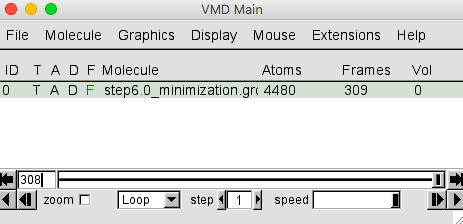

Once you have the molecule and the trajectory uploaded to VMD try to change the representation of the fullerene molecules to VDW, so that you could clearly see whether the fullerene molecules aggregate in water. Go to "Graphics" -> "Representations", make a new replica of the system by clicking "Create rep". Now let's change the representation of the molecules in that replica by choosing the "VDW" for the drawing method. You will see that now all the beads are represented with balls instead of just points. Then in the text input field replace "all" with "resname F16" and press "enter" on the keyboard. It will make only the fullerene molecules (called here F16) to have the ball representation. Another step to make the visualization more efficient is to make the representation orthographic. Go to menu "Display" and click "Orthographic" in the list. There are more options, such as coloring, representation types and many others that you can work with. Most importantly you need to clearly see whether the fullerene molecules aggregate at the end of the simulation. You can make the whole trajectory run by pressing the play button in the left-bottom corner. It is also possible to rotate the entire system by clicking and dragging in the main vizualization window.

***Get a final snapshot of the simulation. Explain if the result is expected i.e., whether fullerene is supposed to be aggregated?***

# Part 2: Simulation of fullerenes next to the membrane

In this part we will simulate a simple membrane model in presence of the fullerene nanoparticles. The membranes can often be constructed via existing tools and scripts, as well as with Packmol (feel free to read the Part 1, it is described in more details there). Nevertheless, in this lab we will not focus on creating a membrane. Interested reader is recommended to go through [Justin Lemkul's tutorial on a membrane-protein system](http://www.mdtutorials.com/gmx/membrane_protein/index.html) with Gromacs.

It is also a good (but not necessary right now) training to compile your own membrane with [CHARMM-GUI tool, though registration is needed on the website](https://charmm-gui.org/?doc=input/martini.bilayer).

You can download the archive Part2 from the studium page of the lab and unfold it on your own laptop or from virtual server. For the latter option you can install Microsoft Remote Desktop if you haven't yet and login to the server its-srv045.its.uu.se using your student-ID and password A. That remote server is a Linux-based environment, where VMD is already installed and you can use browser exactly as you do on your laptop.

We will do some parts of the work here, in jupyter notebook and some in VMD on your laptop/remote desktop.

Let's start with looking at the membrane, already compiled with CHARMM-GUI, the file is called "dopc_bilayer.gro".

In [ ]:
# Change to the Part 2 directory
import os
os.chdir('/content/3FG005/Lab04_Nanoparticles/Part2')
!pwd

In [ ]:
# See what is in the head and tail of the membrane file

!echo -e "First ten lines:\n"
!head -n 10 dopc_bilayer.gro
!echo -e "\n Last ten lines:\n"
!tail -n 10 dopc_bilayer.gro

As you can see, there are both DOPC (phospholipid) and W (water) molecules present in the file. The last six columns are coordinates in XYZ space and the rotation of the moleucles around the respective axis.

Now, let's first visualize it here, in colab.


In [ ]:
# Visualise the whole system
import py3Dmol
with open('dopc_bilayer.gro', 'r') as f:
    pdb_data = f.read()

view = py3Dmol.view(width=600, height=400)
view.addModel(pdb_data, 'gro')
view.setStyle({'sphere': {'color': 'spectrum'}})
view.addUnitCell()
view.zoomTo()
view.show()

It is probabluy not as clear as it could be, so at this stage you are recommended to either check how only the lipids would look like, or to load the molecules into VMD and try to play with visualization settings.

In [ ]:
# Visualise the lipids only
import py3Dmol
with open('dopc_bilayer.gro', 'r') as f:
    pdb_data = f.read()

view = py3Dmol.view(width=600, height=400)
view.addModel(pdb_data, 'gro')
view.setStyle({'resn': 'DOPC'}, {'sphere': {'color': 'spectrum'}})
#view.setStyle({'resn': 'DOPC'}, {'sphere': {'color': 'yellow'}})
#view.setStyle({'resn': 'W'}, {'sphere': {'color': 'blue'}})
view.addUnitCell()
view.zoomTo()
view.show()

If you do visualization with VMD, then, first, open with the gro file from the gromacs sub-directory of the Part2 folder. One way to open it is to type in "vmd" in terminal and press the "Enter" button on your keyboard. Once the window opens you can upload the files in the menu "File-New Molecule" and then by selecting the file. After the first one was uploaded you can select the molecule in the list in the "VMD Main" window by clicking on it (it will become grey, you can also see the screenshot in the Part 1) and choose "File-Load Data into Molecule" to add more configurations. Once you have the trajectory uploaded, change the  representation of the molecules, so that the membrane would be clearly visible. Go to "Graphics" -> "Representations", make a new replica of the system by clicking "Create rep". Now let's change the representation of the molecules in that replica by choosing the "VDW" for the drawing method. You will see that now all the beads are represented with balls instead of just points. You can rotate the system in the main representation window (mostly black screen). Then in the text input field replace "all" with "resname DOPC" and press "enter" on the keyboard. It will then be only the membrane molecules (DOPC) that will be represented with spherical beads, whereas the rest of the molecules (water) will remain as dots. If you go to Extensions menu in VMD and click Tk console, you will get a command line. In this command line type in "pbc box" and push "Enter" key. You are supposed to see the borders of the simulation box, depicted with blue lines.

As you can probably see both from VMD and from the colab visualization, there is not much space in the box to squeeze fullerenes in (especially if you are using VDW representation for the molecules). Thus, we will need to use a slightly modified version of the **gmx insert-molecules** command. Take a look at the gromacs manual for this command. Is there any way to replace some of the existing molecules with fullerenes? Reading manuals is an essential part of computer simulations, at least at the early stages, and we can strongly recommend you to try to come up with the solution here by yourself, before going further in the tutorial. If you need a tip: it is the water molecules that we will replace with fullerenes, as we don't want to set up the insertion of the nanoparticles in a completely artificial way (by plugging it directly into a membrane).

In [ ]:
#The command you are expected to write here is:

!gmx insert-molecules -f dopc_bilayer.gro -ci F16.gro -o F16_and_membrane.gro -replace W -nmol 10

#where 10 is the number of the nanoparticles for insertion.

In this example 10 fullerenes were inserted instead of ~40-50 water molecules (it says atoms, but it is rather coarse-grained beads, representing more than one atom each). In your case the number of water molecules replaced with fullerenes can be different. Take a closer look at the lines in the end of the output:

*Added 10 molecules (out of 10 requested)*

*Replaced X residues (X atoms)*

Now you would have everything ready to run the script that would equilibrate the system. Take a look at the new system.

In [ ]:
# Visualise the system with F16

import py3Dmol
with open('F16_and_membrane.gro', 'r') as f:
    pdb_data = f.read()

view = py3Dmol.view(width=600, height=400)
view.addModel(pdb_data, 'gro')
view.setStyle({'sphere': {'color': 'spectrum'}})
view.setStyle({'resn': 'F16'}, {'sphere': {'color': 'white'}})

view.addUnitCell()
view.zoomTo()
view.show()

If you want to visualize it with VMD, upload the file and set POPC and membrane as VDW in menu Graphics - Representations. Create two more replicas and replace for one of them "all" with "resname F16" and for another "all" with "resname DOPC". Then for both of them change drawing method to "VDW". Now you should be able to see the same system you had before but with some number of fullerenes added.

Now it would be the time to run the script that would in several steps equilibrate the system and produce the trajectory files with the fullerene in the vicinity of the membrane. However, we will only run equilibration here and use pre-run files for the production step, in order to streamline the process.

Firstly, we need to edit the .top file with the topology of the system to match what we have in the .gro file. Let's see how many water and other molecules we have in the .gro file and then adjust the random numbers in the .top file accordingly.

In [ ]:
# We can count the number of W by simlpy making a new index file, where those
# would be counted. Mind that the numbers written stand for beads, not for the
# molecules, so we have 10 fullerens (if you used the default number), not 160.

# Just type in "q" and Enter as you are in the interactive regime of the
# command.
!gmx make_ndx -f F16_and_membrane.gro -o index.ndx


Do you see how many water it was?

In [ ]:
# The current numbers of the molecules can be printed with tail command (as the
# lines with the numbers are in the nd of the .top file)
!tail system.top

As you can see, the number of water and fulleren (F16) molecules should be adjusted, whereas DOPC are 128 (with each lipid represented by 14 beads), resulting in the correct 1792, as shown by make_ndx command.

In order to change the numbers we can use "sed" command and replace the existing value (e.g. 25 for F16) with the real one (10), and the same for W.

In [ ]:
!sed -i -e "s/F16 25/F16 10/g" system.top
!sed -i -e "s/W 1395/W 1456/g" system.top
!tail system.top

Now when .top and .gro have the same information about the molecules in the system, we can run the minimization step, just in case we caused some random overlaps by inserting the fullerenes into the system.

In [ ]:
# Run minimization on the assembled system

!gmx grompp -f step6.0_minimization.mdp -o step6.0_minimization.tpr -c F16_and_membrane.gro -r F16_and_membrane.gro -p system.top -n index.ndx -maxwarn 5
!gmx mdrun -deffnm step6.0_minimization

!gmx grompp -f step6.1_minimization.mdp -o step6.1_minimization.tpr -c step6.0_minimization.gro -r F16_and_membrane.gro -p system.top -n index.ndx -maxwarn 5
!gmx mdrun -deffnm step6.1_minimization

Great, now let's equilibrate the system, gradually increasing the timestep in few steps. One needs to use the output of the previous step as an input for the next one, thus it is important to stay focused while doing it manually. An alternative way, that we could use is to use the script instead. A script is a set of commands that are executed according to the programming rules. Feel free to open the script file **Run_equilibration.sh** and look through its structure. You will find that there are several places where the gmx grompp and gmx mdrun are run. They are even run in a "while" loop, which means that the body of the loop will be executed while the condition is met (that all 6 steps of the equilibration are done). The point of that script is to automatise the process of the simulation and to perform the repetitive steps without manual labour.

In [ ]:
# Take a look at the script that will strealine the process of several
# quilibration steps in order to prepare the system for the production run

!cat Run_equilibration2.sh

As coming from one step to another, the timestep ("dt" in the .mdp files) in the simulations will be increased and some other parameters will eventually change. Such scripts are normally either produced by additional software (as in this case, by CHARMM-GUI), or written manually. If some set up is common for many simulations it can also serve a time-saving tool (i.e. you need to run the same simulation at several concentrations or with different nanoparticle or drug molecules - the sequence of the steps would be often the same).

In [ ]:
# Check the timsestep for integration in MD at various equilibration steps
!grep "dt" step*.mdp

In [ ]:
# Run the script that will execute a sequence of molecular dynamics (MD)
# equilibration steps

# Remember that you can hide/show outputs using the arrow at hte top left corner
# of the cell output bellow

import time

start_time = time.time()

!bash ./Run_equilibration2.sh

end_time = time.time()
elapsed_time = end_time - start_time

print(f"\nSystem equilibration completed in {elapsed_time:.2f} seconds.")

Ok, now the system is equlibrated and we can take a look at it at the beginning and at the end of equilibration, prior to working with the production (full-scale) run. Let's omit the water molecules to only focus on the fullerens and DOPC. To do that we can either use other visualization style for the lipids than spheres, or adjust the style of the beads for each replica in VMD in a more flexible manner.

In [ ]:
# Make a copy of the pre-equilibrated box for fullerens only

# First, let's make a new selection by inserting "2 | 4" in the input field,
# followed by "q".
!gmx make_ndx -f step6.2_equilibration.gro -o index.ndx

# Then we can make the system to only include the newly created group of DOPC
# and F16 (type in the group two times)
!gmx editconf -f step6.2_equilibration.gro -n index.ndx -o fullerens_and_DOPC.pdb -c


In [ ]:
# Visualise the system without water
import py3Dmol
with open('fullerens_and_DOPC.pdb', 'r') as f:
    pdb_data = f.read()

view = py3Dmol.view(width=600, height=400)
view.addModel(pdb_data, 'pdb')
view.setStyle({'cross': {'color': 'spectrum', 'opacity': 1.0}})
view.setStyle({'resn': 'F16'}, {'sphere': {'color': 'spectrum', 'opacity': 1.0}})
view.addUnitCell()
view.zoomTo()
view.show()

In [ ]:
# Same, as before: include the newly created group of DOPC
# and F16, use the group DOPC_F16, likely 5.
!gmx editconf -f step6.6_equilibration.gro -n index.ndx -o fullerens_and_DOPC_eq_final.pdb -c


In [ ]:
# Visualise the system without water
import py3Dmol
with open('fullerens_and_DOPC_eq_final.pdb', 'r') as f:
    pdb_data = f.read()

view = py3Dmol.view(width=600, height=400)
view.addModel(pdb_data, 'pdb')
view.setStyle({'cross': {'color': 'spectrum', 'opacity': 1.0}})
view.setStyle({'resn': 'F16'}, {'sphere': {'color': 'spectrum', 'opacity': 1.0}})
view.addUnitCell()
view.zoomTo()
view.show()

Great, now you can see what happened with the system within rather short period of time during the equilibration. We won't run the production simulaiton in the interest of time. Instead you can use the files step7_production.gro and step7_production.xtc to see the evolution of the system on a longer timescale and perform the analysis on it. In order to visualise the whole trajectory you can open the files with VMD.

Here we can take a look at the final configuration of the production step.

In [ ]:
# Same, as before: include the newly created group of DOPC
# and F16, use the group DOPC_F16, likely 5.
!gmx editconf -f step7_production.gro -n index.ndx -o fullerens_and_DOPC_prod_final.pdb -c

In [ ]:
# Visualise the system after the production run (with water invisible)

with open('fullerens_and_DOPC_prod_final.pdb', 'r') as f:
    pdb_data = f.read()

view = py3Dmol.view(width=600, height=400)
view.addModel(pdb_data, 'pdb')
view.setStyle({'cross': {'color': 'spectrum', 'opacity': 1.0}})
view.setStyle({'resn': 'F16'}, {'sphere': {'color': 'spectrum', 'opacity': 1.0}})
view.addUnitCell()
view.zoomTo()
view.show()

In VMD make fullerene and membrane molecules distinguishable and see whether the nanoparticles enter the membrane. ***If they do, are they aggregating within the membrane? Did they aggregate before entering? If you observe the permeation of a cluster of fullerenes molecules. Take snapshots as various steps to show some of these mechanisms.***

# Part 3: Free energy calculation (single fullerene-membrane interactions)

In this part you will need a single fullerene added the original box with a membrane and water. This step is already prepared and the initial configuration you have contains one fullerene molecule in the middle of the membrane. Download and extract the contents of the archive Part3 from the Studium page.

We can first take a look the initial system here, in Jupyter notebook, but in this part we will also visualize the trajectories with VMD too.

In [ ]:
# Change to the Part 3 directory
import os
os.chdir('/content/3FG005/Lab04_Nanoparticles/Part3')
!pwd

In [ ]:
# Visualise the whole system
import py3Dmol
with open('step8_production.gro', 'r') as f:
    pdb_data = f.read()

view = py3Dmol.view(width=600, height=400)
view.addModel(pdb_data, 'gro')
view.setStyle({'sphere': {'color': 'spectrum'}})
view.addUnitCell()
view.zoomTo()
view.show()

As you can see there is a membrane in the middle between two water layers. However, in such setup we cannot really see the fulleren molecule in the middle of the membrane. Let's try to visualize it again, but this time without DOPC.

In [ ]:
# Visualise water and F16 only

with open('step8_production.gro', 'r') as f:
    pdb_data = f.read()

view = py3Dmol.view(width=600, height=400)
view.addModel(pdb_data, 'gro')
view.setStyle({'resn': 'W'}, {'cross': {'color': 'spectrum', 'opacity': 1.0}})
view.setStyle({'resn': 'F16'}, {'sphere': {'color': 'spectrum', 'opacity': 1.0}})
view.addUnitCell()
view.zoomTo()
view.show()

Ok, fulleren is now within the membrane. THe fact that it is not centered in XY-plane doesn't play any role, we will mostly be interested in the free energy profile of F16 along the normal to the membrane. At the same time, the membrane is homogenous and the solvent around it too, meaning that we do not need to compare various patches in XY-plane.

Open the file "step8_production.gro" in VMD. Now change the representation of the molecules, so that the membrane would be clearly visible. Go to "Graphics" -> "Representations", make a new replica of the system by clicking "Create rep". Now let's change the representation of the molecules in that replica by choosing the "VDW" for the drawing method. You will see that now all the beads are represented with balls instead of just points. You can rotate the system in the main representation window (mostly black screen). Then in the text input field replace "all" with "resname F16" and press "enter" on the keyboard. It will then be only the fullerene molecule that will be represented with spherical beads, whereas the rest of the molecules (water and membrane) will remain as dots. Rotate the system so that it is clear where the fullerene molecule is. **Save the picture and include in the report.**

We want to study quantitatively how much more "comfortable" the fullerene would feel inside the membrane (or in water). For that we want to measure the changes in the system free energy, while fixing the position of the nanoparticle at different distances along the normal to the membrane and collecting statistics on the associated energies. Such method of enhanced sampling is called "umbrella sampling". An [excellent tutorial on a similar simulation is also made by Justin Lemkul](http://www.mdtutorials.com/gmx/umbrella/index.html), please read through it to grasp the main idea (but do not do the practical steps now).

Do not hesitate to ask the tutor for clarification if you do not understand the concept.

To illustrate the meaning of this method you can imagine a situation the molecule of interest was highly hydrophilic. Then the molecule would barely get in contact with the membrane and instead it would remain in the aqueous phase. It would then be problematic to study how such molecule would interact with the inner layers of the membrane, as it rarely naturally occurs there. In order to address this problem we can pull it through water and lipid heads region and lipid tails region and fix the molecule along the normal in separate simulations to get enough sampling and measure how the free energy of the system changes. If the molecule is "unhappy" to stay around the lipid tail region the change of the free energy of the system will have a greater difference with the water level, that other places, where the molecule is "happier" to reside (for instance in the lipid head group region). In other words, we will see a rather high region on the free energy profile in the places where the molecule is relatively not comfortable.

In our exercise you will need to take a look at the pull trajectory of the fullerene (away from the membrane).

Let's look at the last lines in the pull_up.mdp file (starting with pull = yes).

In [ ]:
# print the last 17 lines from the .mdp (molecular dynamics parameters) file
!tail -n 17 pull_up.mdp

Compare to the ones described by Justin [in his tutorial](http://www.mdtutorials.com/gmx/umbrella/05_pull.html). Or you can also look up the [manual for the .mdp files](https://manual.gromacs.org/documentation/current/user-guide/mdp-options.html#com-pulling) in gromacs (specifically pull commands).

***What do the lines in our mdp file stand for? Try to understand them or ask questions.***

Let's make an index file with a group DOPC_F16 introduced for the sake of proper thermostat coupling to the molecules. RUn the command below and in the interactive mode type in "2 | 5", enter, then "3 | 4" and then "q" and enter. Mind the newly created index group. It is also present in our MDP file, so it is important to have it present.

In [ ]:
!gmx make_ndx -f step8_production.gro -o index.ndx

In [ ]:
# Let's run the pulling code for the molecule

!gmx grompp -f pull_up.mdp -c step8_production.gro -r step8_production.gro -p system.top -o pull_up.tpr -n index.ndx -maxwarn 5
!gmx mdrun -deffnm pull_up

The simulation will likely take some 5-12 minutes and will end with a crash, as at some point the distance between the two pulled groups will become higher than half of the box in one of the dimensions. But this is ok, as we will still get a trajectory that can be then split into separate snapshots with varying distance between F16 and the membrane center.

Load the step8_production.gro and then pull.xtc (as a trajectory into the molecule) files to VMD. Note how the fullerene molecule is being pulled. For that you would need to have a different representation for the "resname F16" selection, such as VDW.

***Take few snapshots throughout the trajectory.***

Now we would actually need to do the umbrella sampling, namely, fixing the nanoparticle at various distances from the center of the membrane and collecting data on the energy of the system (also covered in the tutorial by Justin Lemkul). If the windows are covering the trajectory sufficiently, we will be able to get the entire free energy profile. However, for each specific window a lot of the computational resources (and waiting time) would be required, thus it is already done for you. There are two sets of the files (samplingA and samplingB). You will need to **enter each of these folders and use the gmx wham command** (see the Lemkul's tutorial again) applied to each of the sets:

http://www.mdtutorials.com/gmx/umbrella/07_analysis.html

Here, we skip few steps, such as splitting the trajectories into separate configurations, running each window and making lists of the windows for .tpr and .xvg files (see the tutorial) but the key concept remains the same.

In [ ]:
# We will start with samplingA, where there are fewer windows than in the
# samplingB

# Change the directory to samplingA and then run the wham on the files
os.chdir('/content/3FG005/Lab04_Nanoparticles/Part3/samplingA')

In [ ]:
# with individual runs where the F16 molecule was fixed on the Z-axis with a
# spring.

!gmx wham -it tpr-files.dat -if pullf-files.dat -o -hist -unit kCal -tol 1e-05
!mv profile.xvg profileA.xvg

Now, when the calculation is done we can take a look at both the histograms and the resulting profile and see if it looks reasonable.

In [ ]:
# Read the data from the .xvg file
# We need to skip lines that start with # or @ as they are comments or metadata
xvg_file = "histo.xvg"
data = []
header_lines = [] # To store header lines for potential legend information

with open(xvg_file, 'r') as f:
    for line in f:
        line = line.strip()
        if line.startswith('#') or line.startswith('@'):
            header_lines.append(line) # Store header lines
        elif line: # Process non-empty lines that are not comments/metadata
            try:
                values = line.split()
                # Convert values to float
                float_values = [float(v) for v in values]
                data.append(float_values)
            except ValueError:
                # Handle potential errors if values cannot be converted to float
                print(f"Skipping line due to parsing error: {line}")
                continue # Skip to the next line

# Convert the list of lists into a NumPy array
data = np.array(data)

# Check if any data was read and if there's more than one column
if data.size == 0 or data.shape[1] < 2:
    print(f"Error: No valid data or not enough columns found in {xvg_file} to plot multiple series.")
else:
    # The first column is the X data
    x_values = data[:, 0]

    # The remaining columns are the Y data series
    y_values = data[:, 1:]
    num_y_series = y_values.shape[1]

    # Plot the data
    plt.figure(figsize=(12, 7)) # Optional: Set the figure size

    # Generate labels for the Y series from header lines if possible
    # XMGRACE often uses '@ s# legend "..."' or '@ y-axis label "..."'
    # We'll try to extract legends if they are in the header
    legends = [f'Series {i+1}' for i in range(num_y_series)] # Default legends
    for h_line in header_lines:
         # Look for '@ s# legend "..."' pattern
        if h_line.startswith('@ s'):
            try:
                parts = h_line.split('"')
                if len(parts) > 1:
                     # Extract series number (e.g., 's1', 's2')
                    s_part = parts[0].split('s')[-1].split()[0]
                    series_index = int(s_part) - 1 # XMGRACE series numbers are 1-based
                    if 0 <= series_index < num_y_series:
                        legend_text = parts[1]
                        legends[series_index] = legend_text
            except:
                # Ignore errors during legend parsing
                pass

        # You might also look for '@ xaxis label' and '@ yaxis label' in header_lines
        # and set plt.xlabel() and plt.ylabel() accordingly.

    # Plot each Y series
    for i in range(num_y_series):
        plt.plot(x_values, y_values[:, i], label=legends[i])

    # Add labels and title (you might need to adjust these manually
    # if not automatically parsed from header)
    plt.xlabel('distance along the reaction coordinate, nm') # Placeholder, try to parse from header
    plt.ylabel('count') # Placeholder, try to parse from header
    plt.title(f'Plot of {xvg_file}') # Example title

    if num_y_series > 1:
        plt.legend() # Show the legend if there's more than one Y series
    plt.grid(True) # Optional: Add a grid
    plt.show()

Does it look like the histograms are covering the whole range and overlap sufficiently? Let's see what the profile will look like.

In [ ]:
# Define the path to your .xvg file
xvg_file = 'profileA.xvg'

# Check if the file exists
if not os.path.exists(xvg_file):
    print(f"Error: {xvg_file} not found. Make sure the file exists.")
else:
    # Read the data from the .xvg file
    # We need to skip lines that start with # or @ as they are comments or metadata
    data = []
    with open(xvg_file, 'r') as f:
        for line in f:
            line = line.strip()
            if not line.startswith(('#', '@')) and line:
                try:
                    # Split the line and convert values to float
                    x, y = line.split()
                    data.append([float(x), float(y)])
                except ValueError:
                    # Handle potential errors if a line doesn't have two numbers
                    print(f"Skipping line due to parsing error: {line}")

    # Convert the list of lists into a NumPy array
    data = np.array(data)

    # Check if any data was read
    if data.size > 0:
        # Extract the columns (time and potential energy)
        time = data[:, 0]
        potential_energy = data[:, 1]

        # Plot the data
        plt.figure(figsize=(10, 6)) # Optional: Set the figure size
        plt.plot(time, potential_energy)

        # Set the y-axis to a logarithmic scale
        #plt.yscale('log')

        plt.xlabel('distance along the reaction coordinate, nm') # Update with the correct unit from your .xvg file if different
        plt.ylabel('Potential Energy (kcal/mol)') # Update with the correct unit
        plt.title('Potential Energy Minimization Profile (Log Scale)')
        plt.grid(True) # Optional: Add a grid
        plt.show()
    else:
        print(f"No valid data found in {xvg_file} to plot.")

It probably isn't good enough. If there are any breaks in the profile we cannot judge on the overall free energy difference between the points, as the profile has to be continious and smooth from the middle of the membrane (0 nm) to the bulk (most remote points on the right part of the graph).

Let's try with a more thorough sampling - samplingB.

In [ ]:
# We continue with the samplingB
# Change the directory to samplingB and then run the wham on the files
os.chdir('/content/3FG005/Lab04_Nanoparticles/Part3/samplingB')



In [ ]:
# with individual runs where the F16 molecule was fixed on the Z-axis with a
# spring.
!gmx wham -it tpr-files.dat -if pullf-files.dat -o -hist -unit kCal -tol 1e-05

Ok, we can take a look at the histograms and the resulting profile of the samplingB and see if this time it looks better.

In [ ]:
# Read the data from the .xvg file
# We need to skip lines that start with # or @ as they are comments or metadata
xvg_file = "histo.xvg"
data = []
header_lines = [] # To store header lines for potential legend information

with open(xvg_file, 'r') as f:
    for line in f:
        line = line.strip()
        if line.startswith('#') or line.startswith('@'):
            header_lines.append(line) # Store header lines
        elif line: # Process non-empty lines that are not comments/metadata
            try:
                values = line.split()
                # Convert values to float
                float_values = [float(v) for v in values]
                data.append(float_values)
            except ValueError:
                # Handle potential errors if values cannot be converted to float
                print(f"Skipping line due to parsing error: {line}")
                continue # Skip to the next line

# Convert the list of lists into a NumPy array
data = np.array(data)

# Check if any data was read and if there's more than one column
if data.size == 0 or data.shape[1] < 2:
    print(f"Error: No valid data or not enough columns found in {xvg_file} to plot multiple series.")
else:
    # The first column is the X data
    x_values = data[:, 0]

    # The remaining columns are the Y data series
    y_values = data[:, 1:]
    num_y_series = y_values.shape[1]

    # Plot the data
    plt.figure(figsize=(12, 7)) # Optional: Set the figure size

    # Generate labels for the Y series from header lines if possible
    # XMGRACE often uses '@ s# legend "..."' or '@ y-axis label "..."'
    # We'll try to extract legends if they are in the header
    legends = [f'Series {i+1}' for i in range(num_y_series)] # Default legends
    for h_line in header_lines:
         # Look for '@ s# legend "..."' pattern
        if h_line.startswith('@ s'):
            try:
                parts = h_line.split('"')
                if len(parts) > 1:
                     # Extract series number (e.g., 's1', 's2')
                    s_part = parts[0].split('s')[-1].split()[0]
                    series_index = int(s_part) - 1 # XMGRACE series numbers are 1-based
                    if 0 <= series_index < num_y_series:
                        legend_text = parts[1]
                        legends[series_index] = legend_text
            except:
                # Ignore errors during legend parsing
                pass

        # You might also look for '@ xaxis label' and '@ yaxis label' in header_lines
        # and set plt.xlabel() and plt.ylabel() accordingly.

    # Plot each Y series
    for i in range(num_y_series):
        plt.plot(x_values, y_values[:, i], label=legends[i])

    # Add labels and title (you might need to adjust these manually
    # if not automatically parsed from header)
    plt.xlabel('distance along the reaction coordinate, nm') # Placeholder, try to parse from header
    plt.ylabel('count') # Placeholder, try to parse from header
    plt.title(f'Plot of {xvg_file}') # Example title

    #if num_y_series > 1:
    #    plt.legend() # Show the legend if there's more than one Y series
    plt.grid(True) # Optional: Add a grid
    plt.show()

Does it cover the whole x axis this time? Let's take a look at the free energy profile.

In [ ]:
# Define the path to your .xvg file
xvg_file = 'profile.xvg'

# Check if the file exists
if not os.path.exists(xvg_file):
    print(f"Error: {xvg_file} not found. Make sure the file exists.")
else:
    # Read the data from the .xvg file
    # We need to skip lines that start with # or @ as they are comments or metadata
    data = []
    with open(xvg_file, 'r') as f:
        for line in f:
            line = line.strip()
            if not line.startswith(('#', '@')) and line:
                try:
                    # Split the line and convert values to float
                    x, y = line.split()
                    data.append([float(x), float(y)])
                except ValueError:
                    # Handle potential errors if a line doesn't have two numbers
                    print(f"Skipping line due to parsing error: {line}")

    # Convert the list of lists into a NumPy array
    data = np.array(data)

    # Check if any data was read
    if data.size > 0:
        # Extract the columns (time and potential energy)
        time = data[:, 0]
        potential_energy = data[:, 1]

        # Plot the data
        plt.figure(figsize=(10, 6)) # Optional: Set the figure size
        plt.plot(time, potential_energy)

        # Set the y-axis to a logarithmic scale
        #plt.yscale('log')

        plt.xlabel('distance along the reaction coordinate, nm') # Update with the correct unit from your .xvg file if different
        plt.ylabel('Potential Energy (kcal/mol)') # Update with the correct unit
        plt.title('Potential Energy Minimization Profile (Log Scale)')
        plt.grid(True) # Optional: Add a grid
        plt.show()
    else:
        print(f"No valid data found in {xvg_file} to plot.")

Save the graphs and reflect on the sufficiency of the sampling in both cases.

**Include this in the report and describe briefly what it means.**